# FGSM 공격 이미지 방어 실험

### 사전 준비
Google Drive에 아래 파일 올려두기:
```
내 드라이브/hanium-aml-defense/hanium_attack_outputs.zip
내 드라이브/hanium-aml-defense/best.pt
```

In [1]:
#  Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 레포 클론
%cd /content
!rm -rf hanium-aml-defense
!git clone https://github.com/Yaho03/26_HC160.git hanium-aml-defense
%cd /content/hanium-aml-defense

/content
Cloning into 'hanium-aml-defense'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 5.61 KiB | 5.61 MiB/s, done.
/content/hanium-aml-defense


In [8]:
# 공격 결과 + 체크포인트 복원
import zipfile, shutil
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive/한이음')
REPO = Path('/content/hanium-aml-defense')

# 공격 결과 압축 해제
zip_path = DRIVE / 'hanium_attack_outputs.zip'
assert zip_path.exists(), f'ZIP 없음: {zip_path}'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(REPO)
print('공격 결과 복원 완료')

# 체크포인트 복사
ckpt_dir = REPO / 'checkpoints' / 'face_resnet50_lfw10'
ckpt_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(DRIVE / 'best.pt', ckpt_dir / 'best.pt')
print('체크포인트 복원 완료')

# 확인
import pandas as pd
idx = pd.read_csv(REPO / 'outputs/attacks/attack_index.csv')
fgsm = idx[idx['attack_family'] == 'fgsm']
print(f'\nFGSM 공격 샘플: {len(fgsm)}장')
print(f' 공격 성공: {fgsm["success_on_clean"].sum()}장')

공격 결과 복원 완료
체크포인트 복원 완료

FGSM 공격 샘플: 223장
 공격 성공: 47장


In [9]:
# FGSM 방어 실행 (먼저 10장으로 테스트)
%cd /content/hanium-aml-defense/src
!python defense_fgsm_only.py --limit 10

/content/hanium-aml-defense/src
[INFO] 모델 로드 완료 (device=cuda)
[INFO] 클래스: ['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Jean_Chretien', 'John_Ashcroft', 'Junichiro_Koizumi', 'Tony_Blair']

[INFO] FGSM 공격 성공 샘플: 10장
[INFO] 방어 기법 3가지 × 10장 = 총 30회 평가

--- jpeg_q75 ---
  Defense Success Rate: 10/10 (100.0%)
  Recovery Rate:        1/10 (10.0%)

--- smoothing_k3 ---
  Defense Success Rate: 6/10 (60.0%)
  Recovery Rate:        2/10 (20.0%)

--- bitdepth_4bit ---
  Defense Success Rate: 7/10 (70.0%)
  Recovery Rate:        1/10 (10.0%)

[DONE] 결과 저장: /content/hanium-aml-defense/outputs/defenses/fgsm_defense_results.csv
[DONE] 총 30행 (방어 3종 × FGSM 샘플 10장)


In [10]:
# 전체 FGSM 샘플 방어 실행
!python defense_fgsm_only.py

[INFO] 모델 로드 완료 (device=cuda)
[INFO] 클래스: ['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Jean_Chretien', 'John_Ashcroft', 'Junichiro_Koizumi', 'Tony_Blair']

[INFO] FGSM 공격 성공 샘플: 47장
[INFO] 방어 기법 3가지 × 47장 = 총 141회 평가

--- jpeg_q75 ---
  Defense Success Rate: 34/47 (72.3%)
  Recovery Rate:        12/47 (25.5%)

--- smoothing_k3 ---
  Defense Success Rate: 32/47 (68.1%)
  Recovery Rate:        19/47 (40.4%)

--- bitdepth_4bit ---
  Defense Success Rate: 30/47 (63.8%)
  Recovery Rate:        12/47 (25.5%)

[DONE] 결과 저장: /content/hanium-aml-defense/outputs/defenses/fgsm_defense_results.csv
[DONE] 총 141행 (방어 3종 × FGSM 샘플 47장)


In [14]:
# 한글 폰트 설치
!apt-get -qq install fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [15]:
# 결과 확인
import pandas as pd

df = pd.read_csv('../outputs/defenses/fgsm_defense_results.csv')

print('=== 방어 기법별 결과 ===')
for defense, g in df.groupby('defense'):
    n = len(g)
    n_def = (g['attack_success_after_defense'] == False).sum()
    n_rec = g['recovered'].sum()
    conf_drop = (g['target_conf_before'] - g['target_conf_after']).mean()
    print(f'\n{defense}:')
    print(f'  Defense Success Rate: {n_def}/{n} ({100*n_def/n:.1f}%)')
    print(f'  Recovery Rate:        {n_rec}/{n} ({100*n_rec/n:.1f}%)')
    print(f'  Avg Confidence Drop:  {conf_drop:.4f}')

=== 방어 기법별 결과 ===

bitdepth_4bit:
  Defense Success Rate: 30/47 (63.8%)
  Recovery Rate:        12/47 (25.5%)
  Avg Confidence Drop:  -0.0229

jpeg_q75:
  Defense Success Rate: 34/47 (72.3%)
  Recovery Rate:        12/47 (25.5%)
  Avg Confidence Drop:  -0.0006

smoothing_k3:
  Defense Success Rate: 32/47 (68.1%)
  Recovery Rate:        19/47 (40.4%)
  Avg Confidence Drop:  -0.0011



=== JPEG (q=75) ===


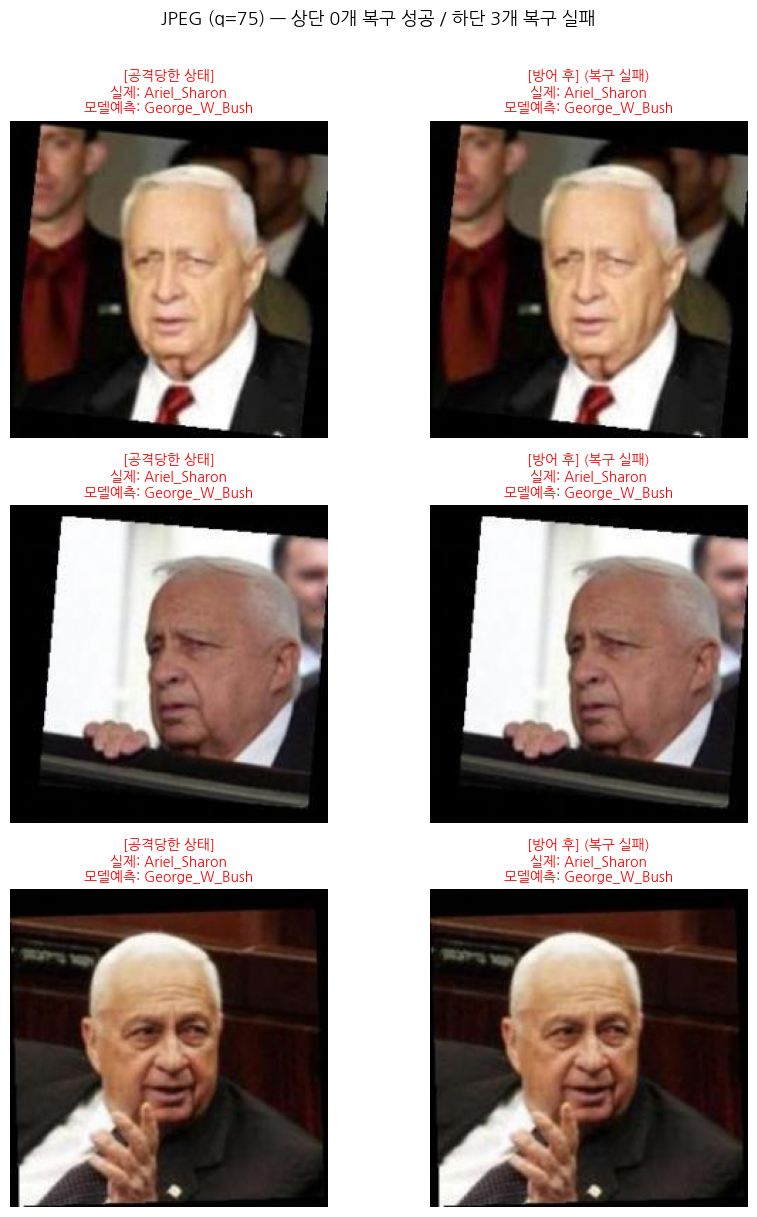


=== Smoothing (k=3) ===


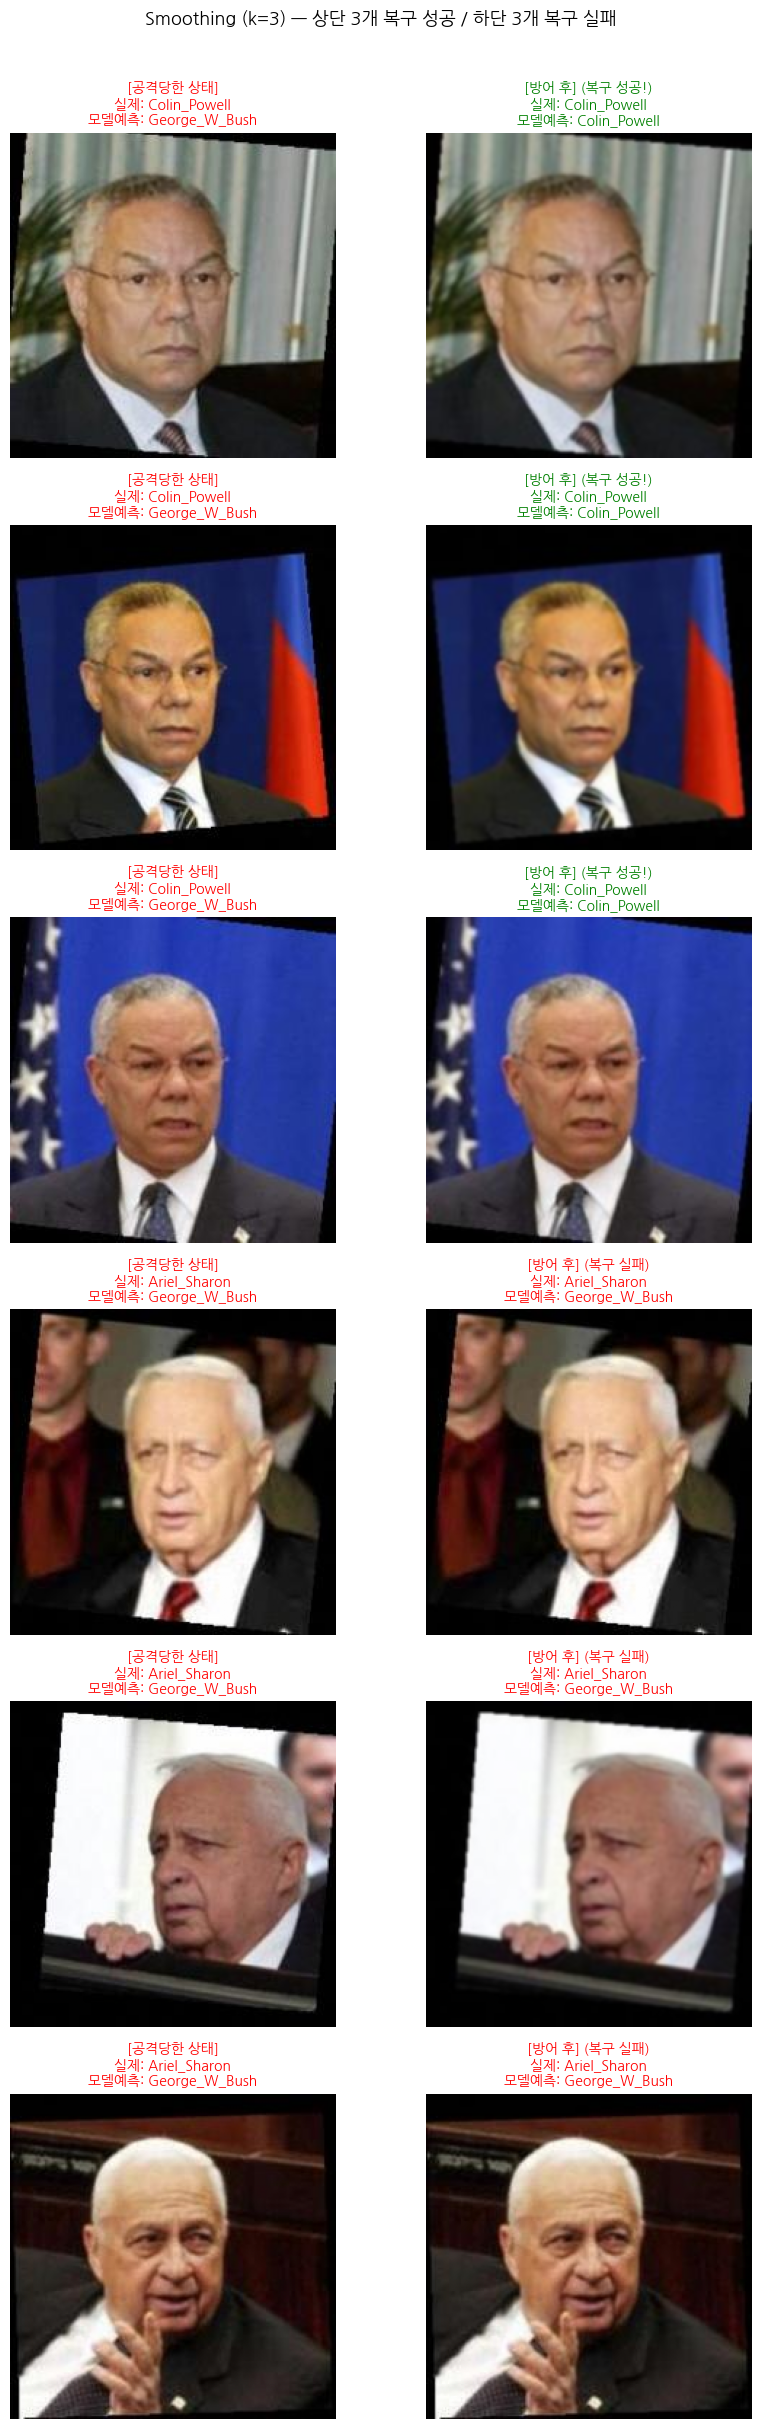


=== BitDepth (4bit) ===


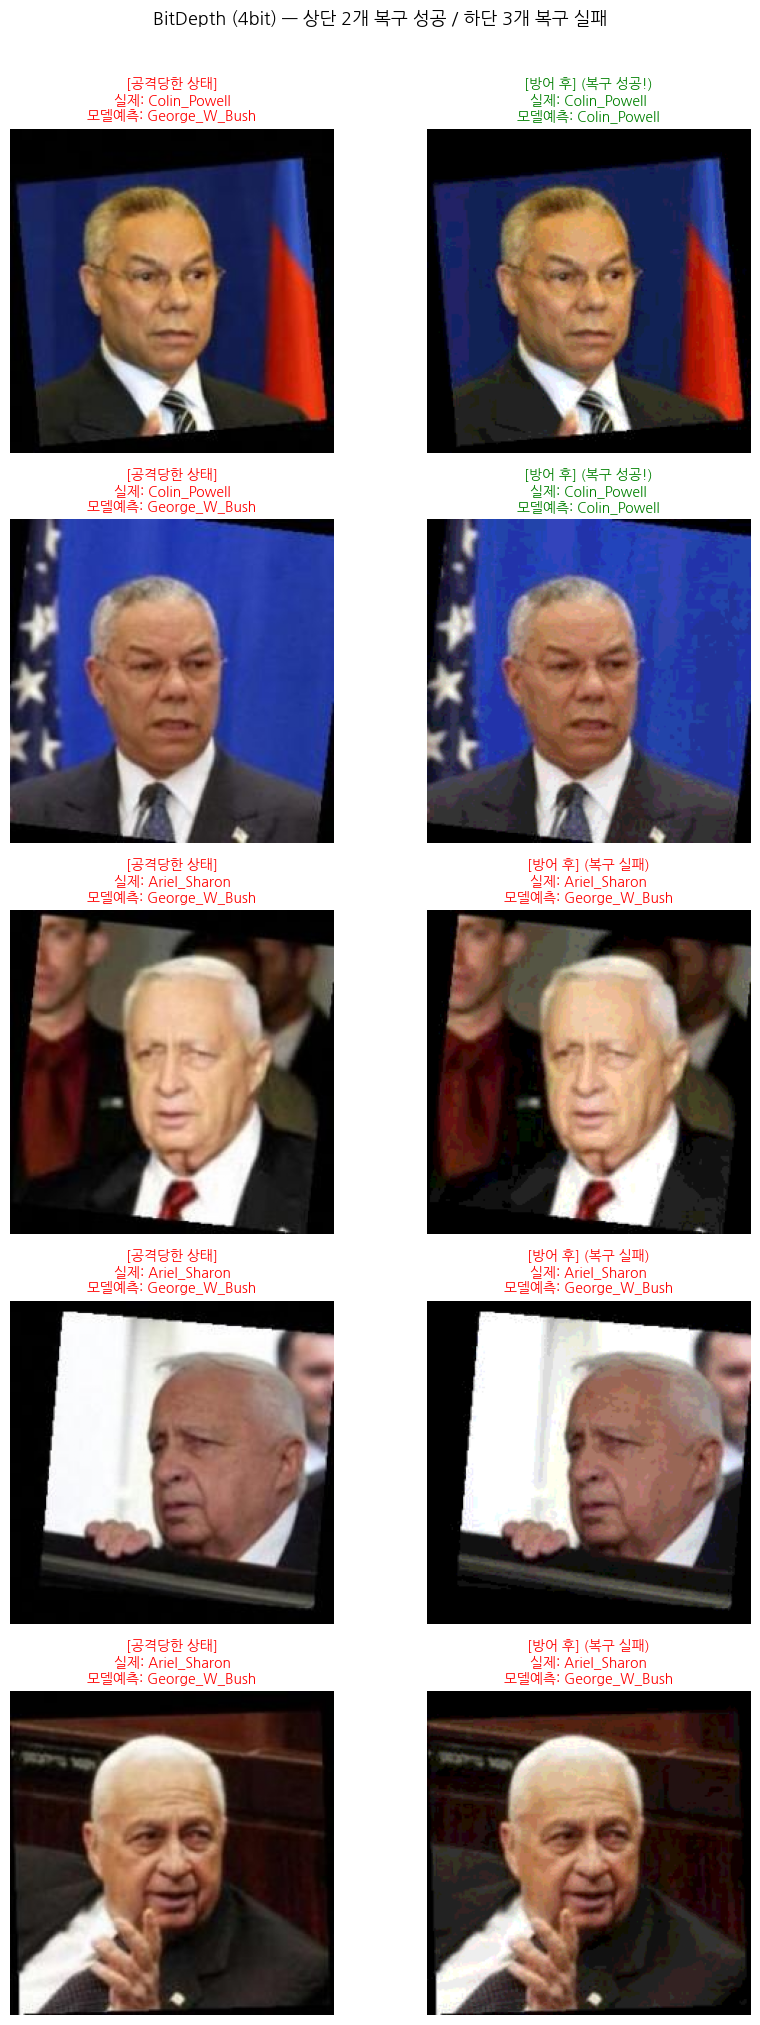

In [19]:
# 방어 전후 시각화 (방어 3종 × 성공3 + 실패3)
import torch
import torchvision.models as models
import torchvision.transforms as T
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import io
import numpy as np

REPO = Path('/content/hanium-aml-defense')
ckpt = torch.load(REPO / 'checkpoints/face_resnet50_lfw10/best.pt',
                   map_location='cpu', weights_only=False)
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 10)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
classes = ckpt['classes']

transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])

# 방어 기법 3가지
def jpeg_defense(img_t, q=75):
    img = T.ToPILImage()(img_t)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=q)
    buf.seek(0)
    return T.ToTensor()(Image.open(buf).convert('RGB').resize((224, 224)))

def smoothing_defense(img_t, k=3):
    return T.GaussianBlur(kernel_size=k, sigma=(0.1, 2.0))(img_t)

def bitdepth_defense(img_t, bits=4):
    levels = 2 ** bits
    return torch.round(img_t * (levels - 1)) / (levels - 1)

defenses = {
    'JPEG (q=75)': lambda img: jpeg_defense(img, 75),
    'Smoothing (k=3)': lambda img: smoothing_defense(img, 3),
    'BitDepth (4bit)': lambda img: bitdepth_defense(img, 4),
}

# FGSM 공격 성공 샘플 전체 스캔
idx = pd.read_csv(REPO / 'outputs/attacks/attack_index.csv')
fgsm = idx[(idx['attack_family']=='fgsm') & (idx['success_on_clean']==True)]

# 각 방어별로 성공/실패 분류
for def_name, def_fn in defenses.items():
    print(f'\n=== {def_name} ===')
    success_samples = []
    fail_samples = []

    for _, row in fgsm.iterrows():
        adv_path = REPO / row['adv_file']
        if not adv_path.exists():
            continue

        adv_img = transform(Image.open(adv_path).convert('RGB'))
        pred_before = model(adv_img.unsqueeze(0)).argmax(1).item()
        true_label = int(row['true_label'])

        # 공격이 실제로 모델을 속인 샘플만 대상
        if pred_before == true_label:
            continue

        defended = def_fn(adv_img)
        pred_after = model(defended.unsqueeze(0)).argmax(1).item()

        info = {'row': row, 'adv_img': adv_img, 'defended': defended,
                'pred_before': pred_before, 'pred_after': pred_after}

        if pred_after == true_label and len(success_samples) < 3:
            success_samples.append(info)
        elif pred_after != true_label and len(fail_samples) < 3:
            fail_samples.append(info)

        if len(success_samples) >= 3 and len(fail_samples) >= 3:
            break

    show = success_samples + fail_samples
    if not show:
        print('  표시할 샘플 없음')
        continue

    n = len(show)
    fig, axes = plt.subplots(n, 2, figsize=(9, 4 * n))
    if n == 1:
        axes = [axes]

    for i, s in enumerate(show):
        row = s['row']
        true_name = row['true_name']
        true_label = int(row['true_label'])
        recovered = s['pred_after'] == true_label

        # 왼쪽: 공격당한 상태
        axes[i][0].imshow(s['adv_img'].permute(1,2,0).numpy())
        axes[i][0].set_title(
            f'[공격당한 상태]\n실제: {true_name}\n모델예측: {classes[s["pred_before"]]}',
            color='red', fontsize=10)
        axes[i][0].axis('off')

        # 오른쪽: 방어 후
        status = '복구 성공!' if recovered else '복구 실패'
        color = 'green' if recovered else 'red'
        axes[i][1].imshow(s['defended'].permute(1,2,0).numpy())
        axes[i][1].set_title(
            f'[방어 후] ({status})\n실제: {true_name}\n모델예측: {classes[s["pred_after"]]}',
            color=color, fontsize=10)
        axes[i][1].axis('off')

    n_suc = len(success_samples)
    plt.suptitle(f'{def_name} — 상단 {n_suc}개 복구 성공 / 하단 {len(fail_samples)}개 복구 실패',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [13]:
#  Drive에 결과 백업
dst = Path('/content/drive/MyDrive/hanium-aml-defense/results')
dst.mkdir(parents=True, exist_ok=True)
!cp /content/hanium-aml-defense/outputs/defenses/fgsm_defense_results.csv {dst}/
print(f'백업 완료: {dst}')

백업 완료: /content/drive/MyDrive/hanium-aml-defense/results
